# Assignment 2: Time-Series, Biological Sequences, and Periodic Graphs
In Assignment 1, we explored how AI models finite, discrete chemical graphs—specifically small molecules and permutation-invariant mixtures.

In Assignment 2, we scale up our spatial and temporal dimensions. We will evaluate the inductive biases required to process the continuous temporal dynamics of chemical plants (Time-Series), the grammatical structures of massive biomolecules (Sequences), and the infinite repeating lattices of solid-state materials (Periodic Graphs).



## Imports and Setups

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q torchinfo torchmetrics fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.3 MB/s eta 0:00:00


In [ ]:
# Core
import os
import urllib.request
import functools
import json

# Numerical & Visual
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm.auto as tqdm
import IPython.display as ipy_display
import umap

# Machine Learning
import sklearn.preprocessing
import sklearn.metrics
import sklearn.decomposition
import sklearn.linear_model
import sklearn.model_selection

# AI & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchmetrics
import torch.utils.data as torch_data

# Transformers
import transformers

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# Exercise 1: Temporal Dynamics and Causal Convolutions (Time-Series) (3.5 pts)

Metal Oxide (MOX) sensors are widely used for environmental monitoring, but they exhibit severe non-linear hysteresis: they react quickly to gas exposure but recover slowly. Standard row-by-row models fail because the instantaneous sensor reading is heavily entangled with its kinetic history.

We will utilize the Dynamic Gas Mixtures dataset ([Fonollosa et al., 2015, DOI: 10.1016/j.snb.2015.03.028](https://doi.org/10.1016/j.snb.2015.03.028)). The data records 16 MOX sensors exposed to randomly changing binary mixtures of Methane ($CH_4$) and Ethylene ($C_2H_4$) continuously for approximately 12 hours.

We designate a chronological **70/10/20 (Train/Validation/Test)** split, explicitly shaded in the background.





In [ ]:
URL = "https://github.com/chemcognition-lab/CHE1148/raw/refs/heads/main/data/gas_mixture_sensors/CH4_C2H4_1Hz.parquet"
FILE_NAME = "CH4_C2H4_1Hz.parquet"
TRAIN_SIZE = .7
VAL_SIZE = .1
TEST_SIZE = 1 - (TRAIN_SIZE+VAL_SIZE)
SEQ_LEN = 120
BATCH_SIZE = 512
EFFICIENT = 15000
PERFORMANT = 0.55
def count_parameters(eval_model):
    return sum(p.numel() for p in eval_model.parameters() if p.requires_grad)



## 1.1 Data Loading

**Dimensionality Reduction:** The raw dataset is massive, recorded at 100 Hz (yielding over 4.1 million rows). Because chemical gas pulses operate on the scale of minutes, 100 Hz is redundant. The data provided has been downsampled to 1 Hz (1 sample per 100 original datapoints), shrinking the footprint significantly while perfectly preserving the chemical kinetics.

In [ ]:
if not os.path.exists(FILE_NAME):
    urllib.request.urlretrieve(URL, FILE_NAME)

df = pd.read_parquet(FILE_NAME)

print(f"Dataset Shape: {df.shape}")

TIME_COL = df.columns[1]
TARGET_COLS = df.columns[2:4]
FEATURE_COLS = df.columns[4:]
NUM_FEATURES = len(FEATURE_COLS)
NUM_TARGETS = len(TARGET_COLS)
print(f"Time Column: {TIME_COL}")
print(f"Target Columns: {TARGET_COLS}")
print(f"Feature Columns: {FEATURE_COLS}")

ipy_display.display(df.head())

Dataset Shape: (41786, 20)
Time Column: time_sec
Target Columns: Index(['methane_ppm', 'ethylene_ppm'], dtype='object')
Feature Columns: Index(['s01_tgs2602', 's02_tgs2602', 's03_tgs2600', 's04_tgs2600',
       's05_tgs2610', 's06_tgs2610', 's07_tgs2620', 's08_tgs2620',
       's09_tgs2602', 's10_tgs2602', 's11_tgs2600', 's12_tgs2600',
       's13_tgs2610', 's14_tgs2610', 's15_tgs2620', 's16_tgs2620'],
      dtype='object')


,mixture_type,time_sec,methane_ppm,ethylene_ppm,s01_tgs2602,s02_tgs2602,s03_tgs2600,s04_tgs2600,s05_tgs2610,s06_tgs2610,s07_tgs2620,s08_tgs2620,s09_tgs2602,s10_tgs2602,s11_tgs2600,s12_tgs2600,s13_tgs2610,s14_tgs2610,s15_tgs2620,s16_tgs2620
0,CH4_C2H4,0.0,0.0,0.0,0.100000,19.345727,0.100000,250.000000,250.000000,0.100000,0.100000,0.100000,11.635585,14.662004,9.866725,9.980314,8.932021,7.909859,10.991759,12.785721
1,CH4_C2H4,1.0,0.0,0.0,0.100000,19.217742,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,11.643545,14.687577,9.900451,9.955697,8.900103,7.926615,11.002734,12.775430
2,CH4_C2H4,2.0,0.0,0.0,250.000000,19.297010,201.480885,161.831938,214.649852,175.384750,171.166931,138.552130,11.589936,14.656363,9.942236,10.028204,8.894700,7.859287,10.967107,12.786865
3,CH4_C2H4,3.0,0.0,0.0,109.724318,19.314714,58.013894,51.388782,57.012543,39.877973,53.554693,45.578332,11.638564,14.619616,9.966016,9.999425,8.863657,7.922581,10.955272,12.763975
4,CH4_C2H4,4.0,0.0,0.0,49.275648,19.419078,28.281543,25.152961,25.825279,18.222653,27.104862,23.066055,11.632607,14.670501,9.908323,9.984300,8.896718,7.898333,10.974419,12.757136


## EDA
Run the provided Exploratory Data Analysis (EDA) code. We visualize the target gases and the sensor responses, utilizing a shaded background to explicitly designate our 80/20 chronological Train/Validation split.

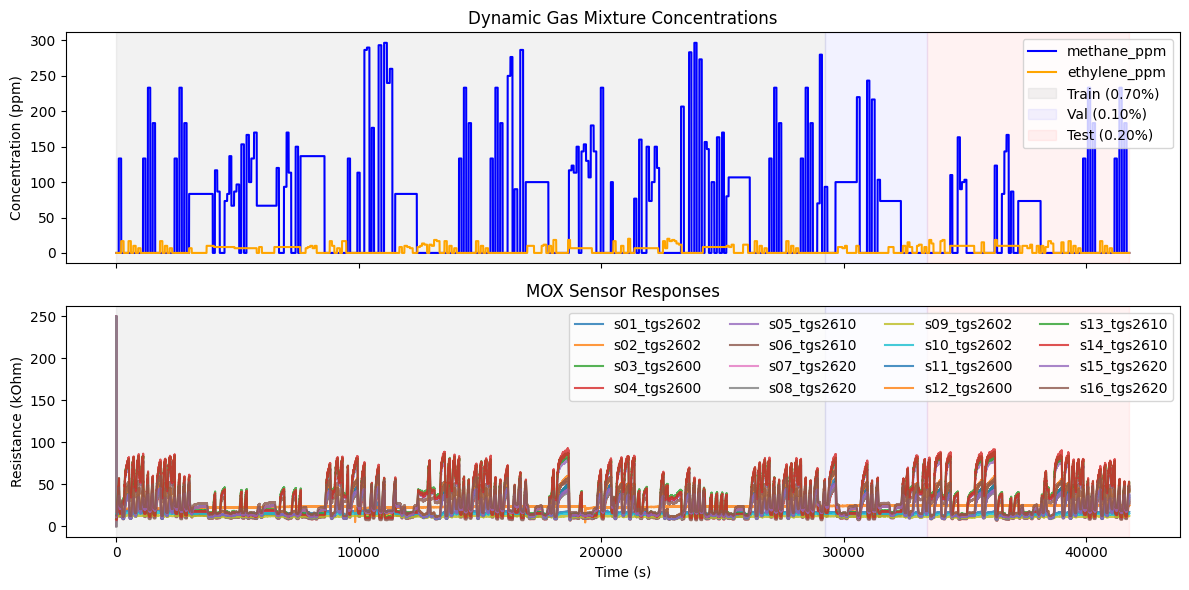

In [ ]:
train_split_idx = int(TRAIN_SIZE* len(df))
val_split_idx = int((TRAIN_SIZE+VAL_SIZE) * len(df))

train_time = df[TIME_COL].iloc[train_split_idx]
val_time = df[TIME_COL].iloc[val_split_idx]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

sns.lineplot(data=df, x=TIME_COL, y=TARGET_COLS[0], ax=axes[0], label=TARGET_COLS[0], color='blue')
sns.lineplot(data=df, x=TIME_COL, y=TARGET_COLS[1], ax=axes[0], label=TARGET_COLS[1], color='orange')
axes[0].axvspan(df[TIME_COL].iloc[0], train_time, color='gray', alpha=0.1, label=f'Train ({TRAIN_SIZE:.2f}%)')
axes[0].axvspan(train_time, val_time, color='blue', alpha=0.05, label=f'Val ({VAL_SIZE:.2f}%)')
axes[0].axvspan(val_time, df[TIME_COL].iloc[-1], color='red', alpha=0.05, label=f'Test ({TEST_SIZE:.2f}%)')
axes[0].set_ylabel("Concentration (ppm)")
axes[0].set_title("Dynamic Gas Mixture Concentrations")
axes[0].legend(loc='upper right')

for col in FEATURE_COLS:
    sns.lineplot(data=df, x=TIME_COL, y=col, ax=axes[1], alpha=0.8, label=col)
axes[1].axvspan(df[TIME_COL].iloc[0], train_time, color='gray', alpha=0.1)
axes[1].axvspan(train_time, val_time, color='blue', alpha=0.05)
axes[1].axvspan(val_time, df[TIME_COL].iloc[-1], color='red', alpha=0.05)
axes[1].set_ylabel("Resistance (kOhm)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("MOX Sensor Responses")
axes[1].legend(loc='upper right', ncols=4)

plt.tight_layout()
plt.show()

### Chronological Splitting & Standard Scaling

We formulate a **Multi-Output Time-Series Regression** task: estimate the instantaneous concentrations of _both_ gases simultaneously from the historical sensor sequence.

Time-series data must never be randomly shuffled during the initial train/validation split. Doing so causes "data leakage" where future states implicitly inform past predictions. Standard scaling must be fit strictly on the training set and applied to the validation set.

---



In [ ]:
x_raw = df[FEATURE_COLS].values
y_raw = df[TARGET_COLS].values

train_idx = int(TRAIN_SIZE * len(x_raw))
val_idx = int((TRAIN_SIZE+VAL_SIZE) * len(x_raw))

x_train_raw = x_raw[:train_idx]
x_val_raw = x_raw[train_idx:val_idx]
x_test_raw = x_raw[val_idx:]

y_train_raw = y_raw[:train_idx]
y_val_raw = y_raw[train_idx:val_idx]
y_test_raw = y_raw[val_idx:]

scaler_x = sklearn.preprocessing.StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train_raw)
x_val_scaled = scaler_x.transform(x_val_raw)
x_test_scaled = scaler_x.transform(x_test_raw)

# Scaler y, when compiting metrics, inverse-transform predictions back to original scale
scaler_y = sklearn.preprocessing.StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)


## 1.2 Time-Series DataLoader (`collate_fn`) (.5 pts)

To efficiently train our network, we must chunk the continuous sequences into historical windows of shape `[batch_size, seq_len, num_features]`.

**Task:**

1. Implement the logic inside `create_collate_fn`. The PyTorch `DataLoader` will pass a list of starting integer indices (`batch_indices`).
    
2. Your function must slice the provided global arrays (`x_data` and `y_data`) to construct the sequence tensors for that specific batch.
    
3. The target $y$ should correspond to the final time step of the given sequence window.
    

_Note: While shuffling individual rows destroys time-series integrity, shuffling the extracted temporal windows during training is acceptable because the causal history is preserved perfectly within the `seq_length` boundary of each window._

**Expected Output:**

- **[Code]** A functional `collate_fn` that returns `x_tensor` and `y_tensor` with the correct dimensions.
    
- **[Text]** Execution without errors.

In [ ]:
def create_time_series_dataloaders(x_train, y_train, x_val, y_val, x_test, y_test, seq_len, batch_size):

    # --- STUDENT IMPLEMENTATION START ---
    def collate_fn(batch_indices, x_data, y_data):
        x_batch = []
        y_batch = []
        for i in batch_indices:
            x_batch.append(x_data[i : i + seq_len])
            y_batch.append(y_data[i + seq_len - 1])

        x_tensor = torch.tensor(np.array(x_batch), dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y_batch), dtype=torch.float32)
        return x_tensor, y_tensor
    # --- STUDENT IMPLEMENTATION END ---

    train_loader = torch_data.DataLoader(
        list(range(len(x_train) - seq_len + 1)), # Fixed off-by-one missing last window
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_fn(b, x_train, y_train)
    )
    val_loader = torch_data.DataLoader(
        list(range(len(x_val) - seq_len + 1)), # Fixed off-by-one missing last window
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_fn(b, x_val, y_val)
    )
    test_loader = torch_data.DataLoader(
        list(range(len(x_test) - seq_len + 1)), # Fixed off-by-one missing last window
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_fn(b, x_test, y_test)
    )

    return train_loader, val_loader, test_loader
# Modified dataloader for scalered y
create_dataloaders = functools.partial(
    create_time_series_dataloaders,
    x_train_scaled, y_train_scaled,
    x_val_scaled, y_val_scaled,
    x_test_scaled, y_test_scaled
)

train_loader, val_loader, test_loader = create_dataloaders(SEQ_LEN, BATCH_SIZE)

## 1.3 Temporal Convolutional Network (TCN) (1.5 pts)

Architectural Paradigm: A standard flat CNN is inefficient for long sequences. Modern TCNs group operations into Residual Blocks. Each block contains causal convolutions, activations, and a skip connection. Furthermore, downsampling should be handled natively inside the model (e.g., via Pooling) to increase the receptive field without adding parameters.

Standard 1D convolutions (`nn.Conv1d`) in PyTorch apply symmetric padding. In forecasting, accessing future timesteps constitutes data leakage. We require **causal convolutions**, where padding is applied exclusively to the "past" (left side). Modern sequence architectures based on convolutions ([Bai et al., 2018, arXiv:1803.01271](https://arxiv.org/abs/1803.01271)) enforce this mathematically by manually applying asymmetric padding using `torch.nn.functional.pad`.


**Task:**

1. Implement the `CausalConv1d` layer. Calculate the left padding dynamically based on the kernel size and dilation.
2. Implement a modular `TCNBlock` with Convolutions, activations, dropout, normalizations and residuals. Will be used in the TCN.
    
3. Build a `GasSensorTCN`. Ensure you utilize a MaxPool1d to reduce the sequence dimensionality before flattening it into the final Linear layer.
    
4. Validate the architecture using `torchinfo.summary()` by passing a dummy batch through the network.

In [ ]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        # --- STUDENT IMPLEMENTATION START ---
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=0, dilation=dilation)
        # --- STUDENT IMPLEMENTATION END ---

    def forward(self, x):
        # --- STUDENT IMPLEMENTATION START ---
        x = F.pad(x, (self.pad, 0))
        return self.conv(x)
        # --- STUDENT IMPLEMENTATION END ---

class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        # --- STUDENT IMPLEMENTATION START ---
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation)
        self.norm1 = nn.BatchNorm1d(out_channels)
        self.gelu = nn.GELU()
        self.drop = nn.Dropout(0.4)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        # --- STUDENT IMPLEMENTATION END ---

    def forward(self, x):
        # --- STUDENT IMPLEMENTATION START ---
        res = x if self.downsample is None else self.downsample(x)
        out = self.gelu(self.norm1(self.conv1(x)))
        out = self.drop(out)
        return self.gelu(out + res)
        # --- STUDENT IMPLEMENTATION END ---

class GasSensorTCN(nn.Module):
    def __init__(self, num_features, num_targets, hidden_dim, seq_len):
        super().__init__()
        # --- STUDENT IMPLEMENTATION START ---
        self.tcn = nn.Sequential(
            TCNBlock(num_features, hidden_dim, kernel_size=3, dilation=1),
            TCNBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2),
            TCNBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4),
            TCNBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=8),
            TCNBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=16),
            TCNBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=32),
        )
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * (seq_len // self.pool.kernel_size), num_targets)
        # --- STUDENT IMPLEMENTATION END ---

    def forward(self, x):
        # --- STUDENT IMPLEMENTATION START ---
        x = x.transpose(1, 2)  # Convert (batch, seq, features) -> (batch, features, seq)
        x = self.tcn(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        return self.fc(x)
        # --- STUDENT IMPLEMENTATION END ---

print("--- CausalConv1d Summary ---")
dummy_conv = CausalConv1d(in_channels=NUM_FEATURES, out_channels=24, kernel_size=5, dilation=1)
print(torchinfo.summary(dummy_conv, input_size=(BATCH_SIZE, NUM_FEATURES, SEQ_LEN), col_names=["input_size", "output_size", "num_params"]))

print("\n--- TCNBlock Summary ---")
dummy_block = TCNBlock(in_channels=NUM_FEATURES, out_channels=24, kernel_size=5, dilation=1)
print(torchinfo.summary(dummy_block, input_size=(BATCH_SIZE, NUM_FEATURES, SEQ_LEN), col_names=["input_size", "output_size", "num_params"]))

print("\n--- GasSensorTCN Summary ---")
dummy_model = GasSensorTCN(num_features=NUM_FEATURES, num_targets=NUM_TARGETS, hidden_dim=24, seq_len=SEQ_LEN)
print(torchinfo.summary(dummy_model, input_size=(BATCH_SIZE, SEQ_LEN, NUM_FEATURES), col_names=["input_size", "output_size", "num_params"]))


--- CausalConv1d Summary ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CausalConv1d                             [512, 16, 120]            [512, 24, 120]            --
├─Conv1d: 1-1                            [512, 16, 124]            [512, 24, 120]            1,944
Total params: 1,944
Trainable params: 1,944
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 119.44
Input size (MB): 3.93
Forward/backward pass size (MB): 11.80
Params size (MB): 0.01
Estimated Total Size (MB): 15.74

--- TCNBlock Summary ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
TCNBlock                                 [512, 16, 120]            [512, 24, 120]            --
├─Conv1d: 1-1                            [512, 16, 120]            [512, 24, 120]            408
├─CausalConv1d: 1-2                      [512, 16, 120]            [512, 24, 120]            --
│    └─Conv1d: 2-1              

### Inference and Evaluation Pipelines

Separate the evaluation logic strictly into two functions: one for performing the forward pass without tracking gradients, and one for statistically evaluating the output tensors.


In [ ]:
def inference(inf_model, dataloader, device):
    inf_model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            outputs = inf_model(x_batch)
            all_preds.append(outputs.cpu())
            all_targets.append(y_batch.cpu())

    return torch.cat(all_targets), torch.cat(all_preds)

def evaluate(targets, predictions, criterion):
    loss = criterion(predictions, targets).item()
    mse = sklearn.metrics.mean_squared_error(targets, predictions)
    mae = sklearn.metrics.mean_absolute_error(targets, predictions)
    r2 = sklearn.metrics.r2_score(targets, predictions)

    return {
        "loss": loss,
        "mse": mse,
        "mae": mae,
        "r2": r2
    }

### 1.4 The Cramming Challenge: Causal Convolutions & Edge AI (1 pts)

MOX sensors are frequently deployed as Edge AI on low-power microcontrollers (e.g., smart home devices, industrial IoT). Memory footprint and inference latency are severely constrained.

**Full marks:** You must design a `GasSensorTCN` utilizing **causal convolutions** (`F.pad` exclusively on the left side) that achieves an $R^2 > 0.55$ on the Test Set.

**Bonus points**, you will evaluate your architecture under two paradigms:

1. **Most Performant: (1 pt)** Unconstrained parameters. Maximize $R^2$.
    
2. **Most Efficient: (1 pt)** You must achieve the $0.55$ threshold utilizing a model with **strictly fewer than 15,000 parameters**.


### Below is for Most Efficient Model ###

In [ ]:
import random
import copy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

EPOCHS = 50
LR = 0.0001 # reduced from 0.001 to 0.0001 for more stable convergence
HIDDEN_DIM = 24 # reduced from 64, preveting overfitting and reducing parameter numbers
BATCH_SIZE = 128 # reduced from 256 for better generalization
SEQ_LEN = 120

model = GasSensorTCN(NUM_FEATURES, NUM_TARGETS, HIDDEN_DIM, SEQ_LEN)
model = model.to(DEVICE)
criterion = nn.MSELoss()

# optimizer from Adam to AdamW for better weight decay handling
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

train_loader, val_loader, test_loader = create_dataloaders(SEQ_LEN, BATCH_SIZE)

# added OneCycleLR scheduler
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    div_factor=10,
    final_div_factor=100
)

num_params = count_parameters(model)
print(f"Total Trainable Parameters: {num_params:,}")
print(f"Efficiency Status: {'✅ Passed' if num_params < EFFICIENT else '❌ Failed'} (< 15k params required)")

Total Trainable Parameters: 13,514
Efficiency Status: ✅ Passed (< 15k params required)


In [ ]:
history = []
pbar = tqdm.tqdm(range(EPOCHS))

# added early stopping
best_val_r2 = -float('inf')
best_model_weights = None
patience = 20
epochs_no_improve = 0

for epoch in pbar:
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        # added scheduler.step()
        scheduler.step()

    train_targets, train_preds = inference(model, train_loader, DEVICE)
    val_targets, val_preds = inference(model, val_loader, DEVICE)

    # inverse transforme to evaluate in original ppm space
    train_targets = torch.tensor(scaler_y.inverse_transform(train_targets), dtype=torch.float32)
    train_preds = torch.tensor(scaler_y.inverse_transform(train_preds), dtype=torch.float32)
    val_targets = torch.tensor(scaler_y.inverse_transform(val_targets), dtype=torch.float32)
    val_preds = torch.tensor(scaler_y.inverse_transform(val_preds), dtype=torch.float32)

    train_metrics = evaluate(train_targets, train_preds, criterion)
    val_metrics = evaluate(val_targets, val_preds, criterion)

    # Early Stopping
    if val_metrics['r2'] > best_val_r2:
        best_val_r2 = val_metrics['r2']
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    history.append({'epoch': epoch + 1, 'split': 'train'} | train_metrics)
    history.append({'epoch': epoch + 1, 'split': 'val'} | val_metrics)

    # Display the current LR and Val R2 in the progress bar
    current_lr = optimizer.param_groups[0]['lr']
    pbar.set_postfix({'val_loss': f"{val_metrics['loss']:.2f}", 'val_r2': f"{val_metrics['r2']:.4f}", 'best_r2': f"{best_val_r2:.4f}"})

    # break condition when patience is exceeded
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        break

# Restore the best model weights after training finishes
if best_model_weights is not None:
    print(f"\nRestoring best model weights with Val R2: {best_val_r2:.4f}")
    model.load_state_dict(best_model_weights)

df_history = pd.DataFrame(history)

  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping triggered at epoch 50!

Restoring best model weights with Val R2: 0.5179


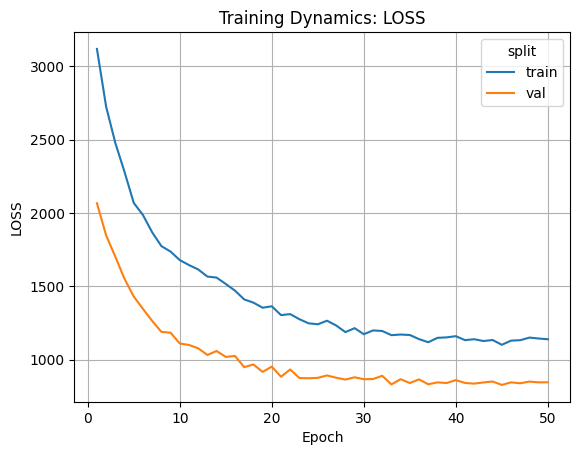

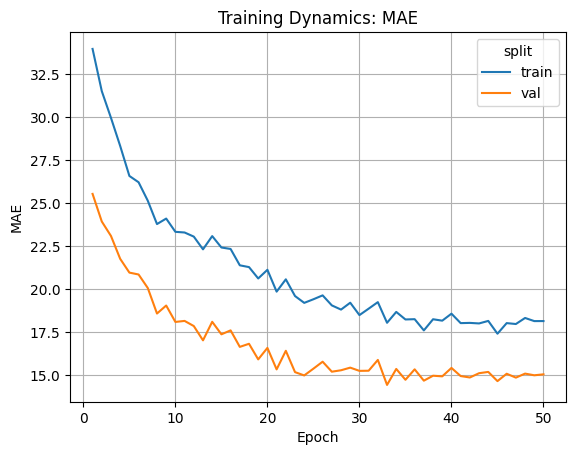

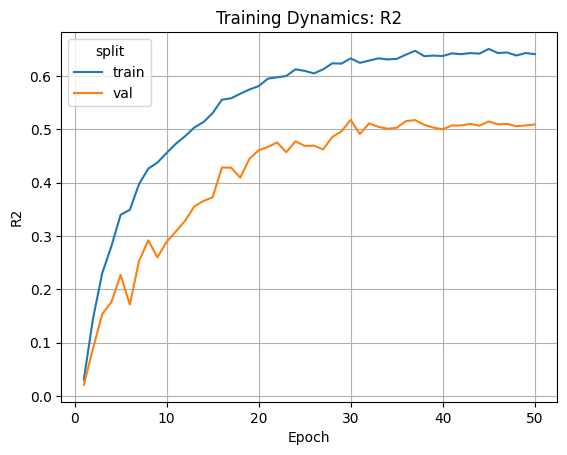

In [ ]:
for metric in ["loss", "mae", "r2"]:
    plt.gca()
    sns.lineplot(data=df_history, x="epoch", y=metric, hue="split")
    plt.title(f"Training Dynamics: {metric.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.grid(True)
    plt.show()

## Final Test Evaluation

Evaluate your fully trained model strictly on the held-out test set to ensure your $R^2$ exceeds the $0.6$ threshold.

In [ ]:
test_targets, test_preds = inference(model, test_loader, DEVICE)

# inverse transform to original ppm space
test_targets = torch.tensor(scaler_y.inverse_transform(test_targets), dtype=torch.float32)
test_preds = torch.tensor(scaler_y.inverse_transform(test_preds), dtype=torch.float32)

test_metrics = evaluate(test_targets, test_preds, criterion)
print(f"Performance Status: {'✅ Passed' if test_metrics['r2'] > PERFORMANT else '❌ Failed'} (R2 > {PERFORMANT} required)")
pd.DataFrame([test_metrics])

Performance Status: ✅ Passed (R2 > 0.55 required)


,loss,mse,mae,r2
0,654.925171,654.925202,14.018849,0.600449


## 1.5 Conceptual Reflection: Modeling Time and Metrics (.5 pts)

**Essay:**

1. **Architectural Trade-offs:** Beyond CNNs, Recurrent Neural Networks (RNNs/LSTMs) and Transformers are commonly utilized for multivariate time-series forecasting. Discuss the primary computational and representational trade-offs when choosing between a CNN, an RNN, and a Transformer for processing continuous chemical sensor data at scale.

2. **Evaluation Metrics:** We formulated this as a regression problem utilizing Mean Squared Error (MSE) and $R^2$. If we were to re-formulate this as a rare event classification problem (e.g., detecting if the gas concentration suddenly spikes above dangerous threshold levels), explain why global accuracy becomes a mathematically misleading metric. Justify what alternative metric you would use to evaluate the predictive utility.

3. **Cramming Challenge Essay:** Report your final performance on the Test Set. Discuss your strategy for the two challenges:
    
    - **Most Performant:** What specific architectural choices (e.g., dilations, layers, hidden dims) maximized your $R^2$ when unconstrained?
        
    - **Most Efficient (< 15k params):** How did you reduce the parameter count while maintaining an $R^2 > 0.55$? What trade-offs or bottlenecks did you observe when heavily restricting the parameter count?

**My most performant** model had $R^2$ of 0.60 with 13,514 parameters (the same with the most efficient model).

**My most efficient** model had $R^2$ of 0.60 with 13,514 parameters.

**1. Architectural trade-offs**

*   **CNN (TCN):** CNN is computationally efficient, because convolutional filters can be applied in parallel across the sequence. It can use dilation, achieving a large receptive field with relatively few parameters. But, it has to be conducted within fixed-length time windows.
*   **RNN/LSTM:** RNN processes data sequentially, maintaining a continuous hidden state, so it allows for variable-length inputs. But, it can not train parallely, leading to slow training speed. Besides, it also suffers from vanishing gradients over long sequences, though LSTM mitigates this.
*   **Transformer:** Transformer utilizes global self-attention, which means every time step directly connects to each other, making it unparalleled at capturing complex, long-range dependencies. The primary problem is high computional cost, because standard self-attention has higher complexity $O(N^2)$ with respect to sequence length. And, it is easy to overfit for low-dimensional sensor data.

**2. Evaluation metrics**

*   Rare event means imbalanced data distribution. For example, if a rare event only occur 1% of the time, a model that constantly predicts as "safe" will achieve 99% accuracy while having a 0% success rate for this rare event. So, for this condition, the accuracy can not reflect the reality.

*   I will choose AUPRC (Area Under the Precision-Recall Curve). It calculates the area under the curve obtained by plotting precision against recall across all classification thresholds, which summarizes how precision changes as recall increases over all thresholds.

**3. Cramming Challenge Essay**

*   **Most Performant:** It is the same model with Most Efficient Model, becasue when I tried to use higher `hidden_dim`, the overfitting problem would destory the performance.
*   **Most Efficient (< 15k params):** I added `OneCycleLR` for tuning learning rate, and modified optimizer into `AdamW` for higher ability. By reducing `hidden_dim` to 24, parameter number shrunk significantly. I set exponential dilations (1, 2, 4, 8, 16, 32), which expanded the receptive field to cover the entire sequence using relatively few parameters. The main problem was a severe overfitting. So, I set a high Dropout (0.4).

# Exercise 2: Protein Embeddings & EDA (2pts)


**Based on:** *[Language models of protein sequences at the scale of evolution enable accurate structure prediction (Lin et al., 2022)](https://www.biorxiv.org/content/10.1101/2022.07.20.500902v1)*

Historically, mapping evolutionary and functional relationships between proteins required computationally expensive Multiple Sequence Alignments (MSAs). However, as demonstrated by the development of the Evolutionary Scale Modeling (ESM) architecture, scaling up language models over hundreds of millions of protein sequences forces the neural network to learn an atomic-level physical understanding of biology.

Trained via a masked language modeling objective, these bidirectional transformers bypass MSAs entirely, projecting variable-length amino acid strings into dense, continuous numerical matrices.

In this exercise, we will ingest a curated Swiss-Prot dataset, preprocess its heterogeneous biological features, compute fixed-size embeddings using different tensor pooling strategies on the lightweight `esm2_t6_8M_UR50D` model, and evaluate the topological quality of our latent spaces using both visual Exploratory Data Analysis (EDA) and quantitative Linear Probing.

## 2.0 Setup: Download data and setup dataframe

In [ ]:
DATA_URL = "https://github.com/chemcognition-lab/CHE1148/raw/refs/heads/main/data/swissprot_eda/proteins_tax_pfam.parquet"
META_URL = "https://raw.githubusercontent.com/chemcognition-lab/CHE1148/refs/heads/main/data/swissprot_eda/metadata.json"

DATA_FILE = "proteins_tax_pfam.parquet"
META_FILE = "metadata.json"

if not os.path.exists(DATA_FILE):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

if not os.path.exists(META_FILE):
    print("Downloading metadata...")
    urllib.request.urlretrieve(META_URL, META_FILE)

In [ ]:
df_proteins = pd.read_parquet(DATA_FILE)
print(f"Dataset Shape: {df_proteins.shape}")
display(df_proteins.head(10)) # added number from 3 to 10, for looking more details

Dataset Shape: (37315, 12)


,accession,protein_name,sequence,length,mass,organism_name,taxonomic_domain,protein_family,pfam_id,go_id,eco_id,pdb_id
0,D4GWB3,Small ribosomal subunit protein aS21 (Small CP...,MSESEQRHAHQCVSCGINIAGMSAATFKCPDCGQEISRCSKCRKQS...,59,6432,Haloferax volcanii (strain ATCC 29605 / DSM 37...,Archaea,Ribosomal,PF07754,0008270;0097590;0090606,0000255,6YDH
1,G1TZ76,Small ribosomal subunit protein eS27 (40S ribo...,MPLAKDLLHPSPEEEKRKHKKKRLVQSPNSYFMDVKCPGCYKITTV...,84,9461,Oryctolagus cuniculus (Rabbit),Eukarya,Ribosomal,PF01667,0022626;0022627;0014069;0032040;0003735;000827...,0000269;0000269;0000269;0000269;0000269;000026...,3JAG;3JAH;3JAI;4D5L;4D61;4KZX;4KZY;4KZZ;5K0Y;5...
2,O14455,Large ribosomal subunit protein eL36B (60S rib...,MAVKTGIAIGLNKGKKVTQMTPAPKISYKKGAASNRTKFVRSLVRE...,100,11135,Saccharomyces cerevisiae (strain ATCC 204508 /...,Eukarya,Ribosomal,PF01158,0005829;0022625;0003723;0003735;0002181;018002...,0000269;0000269,6EM1;6EM3;6EM4;6EM5
3,O55142,Large ribosomal subunit protein eL33 (60S ribo...,MSGRLWCKAIFAGYKRGLRNQREHTALLKIEGVYARDETEFYLGKR...,110,12554,Mus musculus (Mouse),Eukarya,Ribosomal,PF01247,0005737;0005829;0022625;0022626;0005739;009879...,0000269,6SWA;7CPU;7CPV;7LS1;7LS2
4,O60783,Small ribosomal subunit protein uS14m (28S rib...,MAAFMLGSLLRTFKQMVPSSASGQVRSHYVDWRMWRDVKRRKMAYE...,128,15139,Homo sapiens (Human),Eukarya,Ribosomal,PF00253,0005743;0005761;0005763;0005739;0031965;000372...,0000269,3J9M;6NU2;6NU3;6RW4;6RW5;6VLZ;6VMI;6ZM5;6ZM6;6...
5,O65686,Small ribosomal subunit protein bS16cy (30S ri...,MTVKIRLARLGCKHRPFYRVVVADEKSRRDGKQIEVLGFYDPLQGK...,113,12699,Arabidopsis thaliana (Mouse-ear cress),Eukarya,Ribosomal,PF00886,0009507;0009941;0005886;0009536;0005840;001593...,0000269;0000269,
6,O75012,Small ribosomal subunit protein mS37 (37S ribo...,MSGKPPVYRLPPLPRLKVKKPIIRQEANKCLVLMSNLLQCWSSYGH...,95,10691,Saccharomyces cerevisiae (strain ATCC 204508 /...,Eukarya,Ribosomal,PF06747,0005743;0005763;0003735;0032543,0000269;0000269;0000269,5MRC;5MRE;5MRF;8D8K;8D8L;8OM2;8OM3;8OM4;8R8B
7,O76927,Small ribosomal subunit protein eS21 (40S ribo...,MENDAGENVDLYVPRKCSASNRIIHAKDHASVQLSIVDVDPETGRQ...,83,9167,Drosophila melanogaster (Fruit fly),Eukarya,Ribosomal,PF01249,0022626;0022627;0005840;0005791;0043022;000373...,0000250;0000269;0000305;0000250;0000250;0000250,4V6W;6XU6;6XU7;6XU8
8,O82204,Large ribosomal subunit protein eL28z (60S rib...,MATVPGQLIWEIVKNNNCFLVKQFGRGNSKVQFSKETNNLTNVHSY...,143,15895,Arabidopsis thaliana (Mouse-ear cress),Eukarya,Ribosomal,PF01778,0009507;0005737;0022625;0022626;0005739;000573...,0000269;0000269;0000269;0000269,
9,P02358,Small ribosomal subunit protein bS6 (30S ribos...,MRHYEIVFMVHPDQSEQVPGMIERYTAAITGAEGKIHRLEDWGRRQ...,135,15703,Escherichia coli (strain K12),Bacteria,Ribosomal,PF01250,0005737;0005829;0022627;0048027;0070181;000373...,,1EG0;2YKR;3IY8;3J9Y;3J9Z;3JA1;3JBU;3JBV;3JCD;3...


In [ ]:
with open(META_FILE, "r") as f:
    metadata = json.load(f)
print("\nDataset Metadata Configuration:")
print(json.dumps(metadata, indent=4))


Dataset Metadata Configuration:
{
    "description": "Curated dataset of diverse protein families from the UniProtKB (Swiss-Prot) database. Designed for Exploratory Data Analysis of high-dimensional protein language model (ESM-2) latent spaces, capturing evolutionary taxonomy, structural motifs, and functional GO terms.",
    "date_accessed": "2026-03-23T16:18:53.520106",
    "source": "UniProt Swiss-Prot",
    "query": "(reviewed:true) AND (length:[30 TO 150])",
    "go_mapping": {
        "0008270": "zinc ion binding",
        "0097590": "archaeal-type flagellum-dependent cell motility",
        "0090606": "single-species surface biofilm formation",
        "0022626": "cytosolic ribosome",
        "0022627": "cytosolic small ribosomal subunit",
        "0014069": "postsynaptic density",
        "0032040": "small-subunit processome",
        "0003735": "structural constituent of ribosome",
        "0042274": "ribosomal small subunit biogenesis",
        "0006364": "rRNA processing",


## 2.1 Feature Preprocessing (.5 pts)

Biological databases are highly heterogeneous. Our dataset contains three fundamentally different types of features, each requiring specific handling before they can be utilized by downstream linear models or neural networks.

**Exercise Task:**

Process the raw biological metadata into machine-learning-ready arrays and store them in a single dictionary named `features`. You must implement the following:

1. **Continuous Features (`length`, `mass`):** Extract these as raw numerical arrays (do not scale or normalize them for this exercise).
    
2. **Multiclass Features (`taxonomic_domain`, `protein_family`):** Encode these mutually exclusive text labels into discrete integers.
    
3. **Multilabel Features (`pfam_id`, `go_id`):** A single protein sequence can contain multiple distinct structural or functional descriptors separated by semicolons. Split these strings and encode each column into its own multi-hot binary matrix.

In [ ]:
features = {}

# Continuous features
features['length'] = df_proteins['length'].values
features['mass'] = df_proteins['mass'].values

# Multiclass features (taxonomic_domain, protein_family)
le_tax = sklearn.preprocessing.LabelEncoder()
features['taxonomic_domain'] = le_tax.fit_transform(df_proteins['taxonomic_domain'])

le_fam = sklearn.preprocessing.LabelEncoder()
features['protein_family'] = le_fam.fit_transform(df_proteins['protein_family'])

# Multilabel features (pfam_id, go_id)
# Split these strings and encode each column into its own multi-hot binary matrix.
pfam_split = df_proteins['pfam_id'].apply(lambda x: x.split(';') if pd.notnull(x) else [])
mlb_pfam = sklearn.preprocessing.MultiLabelBinarizer()
features['pfam_id'] = mlb_pfam.fit_transform(pfam_split)

go_split = df_proteins['go_id'].apply(lambda x: x.split(';') if pd.notnull(x) else [])
mlb_go = sklearn.preprocessing.MultiLabelBinarizer()
features['go_id'] = mlb_go.fit_transform(go_split)

# Feature shapes
print("Extracted Features Shapes:")
for k, v in features.items():
    print(f"{k}: {v.shape}")

Extracted Features Shapes:
length: (37315,)
mass: (37315,)
taxonomic_domain: (37315,)
protein_family: (37315,)
pfam_id: (37315, 179)
go_id: (37315, 964)


## 2.2 ESM-2 Embedding Extraction & Pooling Strategies

The raw output of the ESM-2 transformer is a tensor of shape `[batch_size, sequence_length, hidden_dim]`. To perform our data analysis, we must mathematically aggregate (pool) the variable sequence length dimension into a fixed-size vector of shape `[batch_size, hidden_dim]`.

We will calculate and store three distinct pooling strategies to evaluate which inductive bias best captures the biological topology:

- **BOS (Beginning of Sequence):** Extracting the index `0` token, which aggregates global context via self-attention.
    
- **Mean Pooling:** Averaging the representations of all valid amino acid tokens (strictly masking out padding).
    
- **Max Pooling:** Extracting the maximum activation for each feature dimension across the sequence length.

In [ ]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"
BATCH_SIZE = 64

tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = transformers.EsmModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

sequences = df_proteins["sequence"].tolist()
x_emb_dict = {"bos": [], "mean": [], "max": []}

with torch.no_grad():
    pbar = tqdm.tqdm(range(0, len(sequences), BATCH_SIZE))
    for i in pbar:
        batch_seqs = sequences[i : i + BATCH_SIZE]
        inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1)

        # 1. BOS Token Projection
        bos_tokens = hidden_states[:, 0, :]

        # 2. Masked Mean Pooling
        sum_embeddings = torch.sum(hidden_states * mask, dim=1)
        valid_lengths = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_tokens = sum_embeddings / valid_lengths

        # 3. Masked Max Pooling
        hidden_states_masked = hidden_states.masked_fill(mask == 0, -1e9)
        max_tokens = torch.max(hidden_states_masked, dim=1)[0]

        x_emb_dict["bos"].append(bos_tokens.cpu().numpy())
        x_emb_dict["mean"].append(mean_tokens.cpu().numpy())
        x_emb_dict["max"].append(max_tokens.cpu().numpy())

for strategy in x_emb_dict:
    x_emb_dict[strategy] = np.vstack(x_emb_dict[strategy])
    print(f"Pooled {strategy.upper()} Tensor Shape: {x_emb_dict[strategy].shape}")

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/584 [00:00<?, ?it/s]

Pooled BOS Tensor Shape: (37315, 320)
Pooled MEAN Tensor Shape: (37315, 320)
Pooled MAX Tensor Shape: (37315, 320)


## 2.3 Exploratory Data Analysis (EDA) (.5pt)


High-dimensional manifolds are impossible to interpret directly. We must project the $320$-dimensional latent spaces down to $2$ dimensions using Uniform Manifold Approximation and Projection (UMAP).

**Exercise Task:**

Perform a visual exploratory data analysis on the extracted ESM-2 embeddings.

1. You must fit three independent UMAP projections—one for **each** of our pooling strategies (`bos`, `mean`, `max`).
    
2. Generate independent scatter plots for all three representations.
    
3. Color the data points using your processed labels to visually evaluate which mathematical aggregation strategy produces the cleanest organic clustering of biological families.

Fitting UMAP for BOS pooling...
Fitting UMAP for MEAN pooling...
Fitting UMAP for MAX pooling...


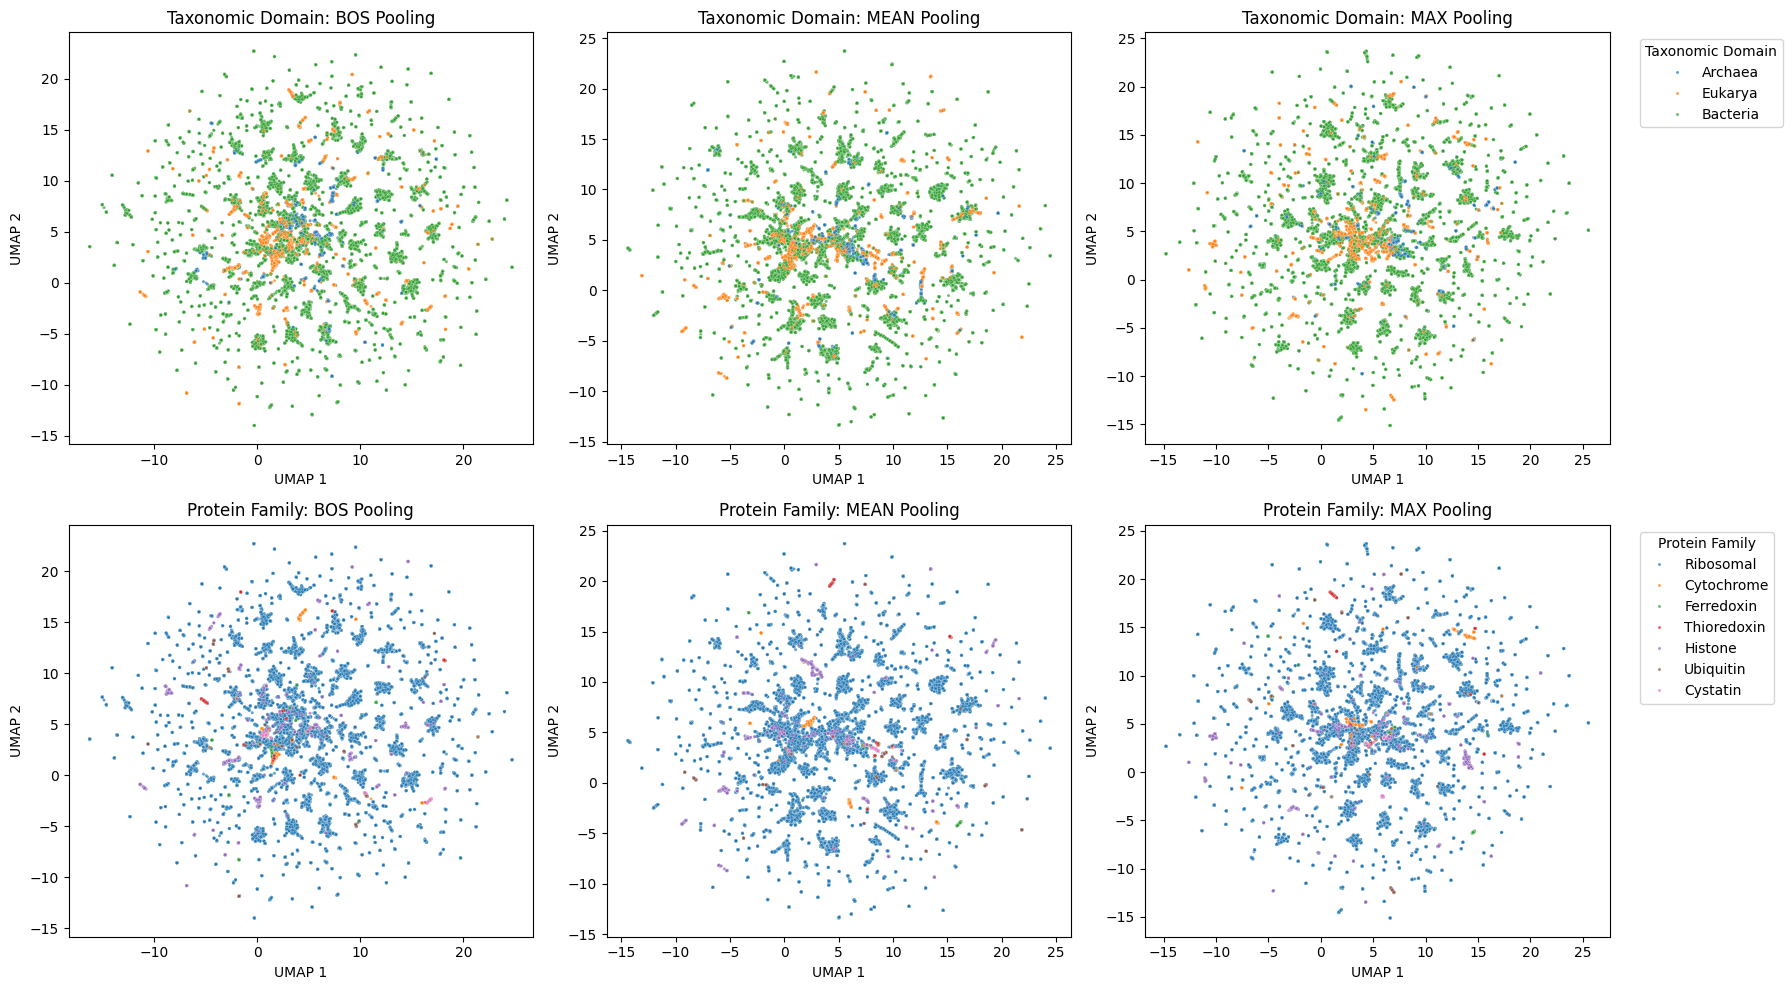

In [ ]:
label_dict = {
    'Taxonomic Domain': df_proteins['taxonomic_domain'],
    'Protein Family': df_proteins['protein_family']
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (strategy, embeddings) in enumerate(x_emb_dict.items()):
    print(f"Fitting UMAP for {strategy.upper()} pooling...")
    reducer = umap.UMAP(n_components=2, random_state=42, init='random', n_jobs=1)
    embedding_2d = reducer.fit_transform(embeddings)

    for row_idx, (label_name, labels) in enumerate(label_dict.items()):
        sns.scatterplot(
            x=embedding_2d[:, 0],
            y=embedding_2d[:, 1],
            hue=labels,
            palette="tab10",
            s=5,
            alpha=0.7,
            ax=axes[row_idx, col_idx],
            legend=(col_idx == 2)
        )
        axes[row_idx, col_idx].set_title(f"{label_name}: {strategy.upper()} Pooling")
        axes[row_idx, col_idx].set_xlabel("UMAP 1")
        axes[row_idx, col_idx].set_ylabel("UMAP 2")

        if col_idx == 2:
            axes[row_idx, col_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=label_name)

plt.tight_layout()
plt.show()

## 2.5 Quantitative Evaluation: Linear Probing (.5pt)
While UMAP provides an intuitive visualization, we must quantitatively measure how linearly separable the biophysical and structural information is within the latent space. We will perform **Linear Probing**: freezing the embeddings and training simple linear models on top of them.

**Exercise Task:**

Systematically evaluate all three pooling strategies (`bos`, `mean`, `max`) across all of the biological features you extracted in your `features` dictionary. You must apply the correct machine learning task based on the feature's mathematical encoding:

1. **Regression (`mass`, `length`):** Predict the continuous arrays using `sklearn.linear_model.Ridge`. Calculate the $R^2$ score.
    
2. **Multiclass Classification (`taxonomy`, `family`):** Predict the discrete integer arrays using `sklearn.linear_model.LogisticRegression`. Calculate Global Accuracy.
    
3. **Multilabel Classification (`pfam`, `go`):** Predict the multi-hot binary matrices using `sklearn.linear_model.RidgeClassifier`. Calculate the Micro F1-Score.
    

Store your evaluation metrics in a single Pandas DataFrame table to easily compare the representational power of each pooling method across all biophysical and evolutionary scales.

In [ ]:
results = []

for strategy, X in x_emb_dict.items():
    print(f"Evaluating {strategy.upper()} pooling...")
    for feature_name, y in features.items():
        # Create a train/test split for evaluation
        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Regression (mass, length)
        if feature_name in ['mass', 'length']:
            model = sklearn.linear_model.Ridge()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            score = sklearn.metrics.r2_score(y_test, preds)
            metric_name = "R2"
            task = "Regression"

        # Multiclass Classification (taxonomy, family)
        elif feature_name in ['taxonomic_domain', 'protein_family']:
            model = sklearn.linear_model.LogisticRegression(max_iter=1000)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            score = sklearn.metrics.accuracy_score(y_test, preds)
            metric_name = "Accuracy"
            task = "Multiclass"

        # Multilabel Classification (pfam, go)
        elif feature_name in ['pfam_id', 'go_id']:
            model = sklearn.linear_model.RidgeClassifier()
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            score = sklearn.metrics.f1_score(y_test, preds, average='micro')
            metric_name = "Micro F1"
            task = "Multilabel"

        results.append({
            "Pooling Strategy": strategy.upper(),
            "Feature": feature_name,
            "Task": task,
            "Metric": metric_name,
            "Score": score
        })

# Consolidate results into a DataFrame
df_results = pd.DataFrame(results)
ipy_display.display(df_results)

Evaluating BOS pooling...
Evaluating MEAN pooling...
Evaluating MAX pooling...


,Pooling Strategy,Feature,Task,Metric,Score
0,BOS,length,Regression,R2,0.951724
1,BOS,mass,Regression,R2,0.947340
2,BOS,taxonomic_domain,Multiclass,Accuracy,0.905132
3,BOS,protein_family,Multiclass,Accuracy,0.990084
4,BOS,pfam_id,Multilabel,Micro F1,0.901308
5,BOS,go_id,Multilabel,Micro F1,0.896616
6,MEAN,length,Regression,R2,0.955020
7,MEAN,mass,Regression,R2,0.951153
8,MEAN,taxonomic_domain,Multiclass,Accuracy,0.910090
9,MEAN,protein_family,Multiclass,Accuracy,0.991022


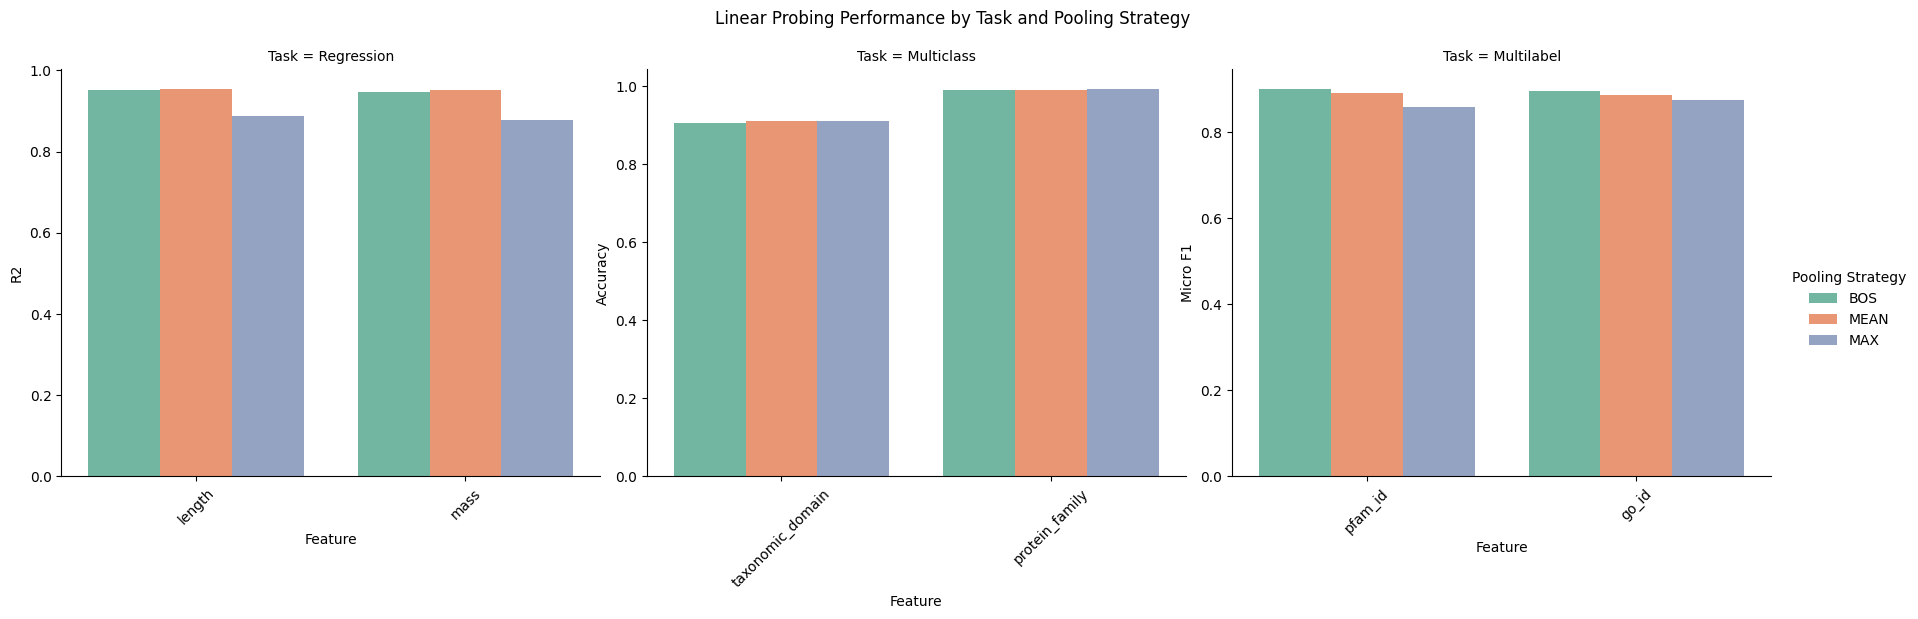

In [ ]:
# Create a grouped bar chart to show the results
g = sns.catplot(
    data=df_results,
    x="Feature",
    y="Score",
    hue="Pooling Strategy",
    col="Task",
    kind="bar",
    sharey=False,
    sharex=False,
    palette="Set2",
    height=5,
    aspect=1.2
)

# Adjust labels and titles
g.set_xticklabels(rotation=45)
g.set_axis_labels("Feature", "")
task_to_metric = {"Regression": "R2", "Multiclass": "Accuracy", "Multilabel": "Micro F1"}
for ax, task in zip(g.axes.flat, g.col_names):
    ax.set_ylabel(task_to_metric.get(task, "Score"))

g.fig.suptitle("Linear Probing Performance by Task and Pooling Strategy", y=1.05)

plt.show()

## 2.6 Conceptual Discussion (.5pt)

**Essay Prompt:**

Review your dataset preprocessing logic and your final Linear Probing performance table. Based on the underlying mathematics and your empirical results, answer the following:

1. **Encoding Schemes:** During preprocessing, we utilized an integer `LabelEncoder` for `protein_family`, but were strictly required to use a `MultiLabelBinarizer` for the `pfam_id` column. Explain the fundamental architectural and biological difference between a _multiclass_ problem and a _multilabel_ problem. Why would applying an integer `LabelEncoder` to the raw `pfam_id` strings mathematically ruin our linear probing task?
    
2. **Representational Trade-offs:** Analyze the performance of your three pooling strategies across the regression, multiclass, and multilabel tasks. Did one pooling strategy strictly dominate the others, or did the performance depend on the specific target? Formulate a brief hypothesis discussing _why_ aggregating the sequence dimension using the `<cls>` (BOS) token might capture different biological inductive biases compared to a strictly unweighted mathematical Mean across the sequence.

##Anwser

**1. Encoding Schemes:**

*   **Architectural and biological difference between a multiclass problem and a multilabel problem: **
*   Multiclass (`protein_family` and `taxonomic_domain`): A protein just belongs to one family/taxonomy. So, the model just needs to predict a single discrete class.
*   Multilabel (`pfam_id` and `go_id`): A protein sequence can contain multiple structural domains or functional motifs. So, the model must be capable of predicting multiple independent binary outcomes.

*   **Why `LabelEncoder` ruins `pfam_id`:**
*  `LabelEncoder` maps unique strings to single integers. But, if a protein possesses two domains (such as `"PF0001;PF0002"`), a `LabelEncoder` treats this as a single, brand-new category (giving it a new integers). This model can not reflect it contains two different motifs, masking the underlying compositional structure. `MultiLabelBinarizer` creates a multi-hot matrix, which can learn and reflect more than one motifs infomration.

**2. Representational Trade-offs:**

*   No single pooling strategy strictly dominated across all tasks, and their performance are really close. But, there are still some differences when they face different works.
*   Regression (mass, and length): MEAN pooling performed best.
*   Multiclass (protein_family and taxonomic_domain, ): MAX pooling performed best.
*   Multilabel (pfam_id and go_id): BOS pooling performed best.

*   **Hypothesis (BOS vs. MEAN):**
*   BOS pooling contains more global strcture/connection information, due to  self-attention. So, it can attend to and summarize complex, long-range biological motifs while ignoring irrelevant padding or noise. This provides a stronger inductive bias for detecting multiple distinct functional domains (pfam) and biological pathways (go).
*   MEAN pooling, however, is gotten from an unweighted mathematical average of all tokens, capturing the overall sequence composition. So, it is highly effective for predicting global, sequence-length-dependent physical properties like mass and length.

# Exercise 3: Biosynthetic Gene Clusters (From Genomes to Graphs) (2 pts)

Based on: Diez et al. (1990) - [*The Cluster of Penicillin Biosynthetic Genes*](https://www.jbc.org/article/S0021-9258(17)46231-4/fulltext)

Biosynthetic gene clusters (BGCs) encode the enzymatic machinery required to synthesize complex secondary metabolites from primary metabolic precursors. In functional genomics, biological data spans multiple coupled modalities: a 1D genetic sequence encodes 1D protein sequences (enzymes), which in turn synthesize and fold a flexible peptide intermediate into a rigid 3D chemical graph.

The BGC for Penicillin, native to the fungus *Penicillium chrysogenum*, contains three primary structural genes: *pcbAB*, *pcbC*, and *penDE*.

In this exercise, you will programmatically extract the data modalities of this cluster, explain the chemical translation process, and formulate a theoretical machine learning problem based on your findings.



## 3.1 Data Modality Traversal (MIBiG Database) (.5 pt)

The Minimum Information about a Biosynthetic Gene cluster (MIBiG) database catalogs experimentally validated BGCs. The Penicillin BGC is recorded under the accession ID **BGC0000404**.

**Task:**
1. Fetch the raw JSON record for BGC0000404 from the MIBiG API.
2. Parse the JSON dictionary to extract the specific nucleotide lengths, amino acid sequences, and SMILES strings associated with the cluster.
3. Populate the `bgc_data` dictionary and print the summary.

*Hint: Inspect the `genes` and `compounds` arrays within the `cluster` object to match the specific structural genes (`pcbAB`, `pcbC`) and the related molecules.*


In [ ]:
# Load JSON
def load_json(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as r:
        return json.load(r)

gene_json = load_json("https://mibig.secondarymetabolites.org/repository/BGC0000404/BGC0000404.json")
ann_json  = load_json("https://mibig.secondarymetabolites.org/repository/BGC0000404.4/annotations.json")

bgc_data = {"genes": {}, "compounds": {}}

# Recursive generator
# Older MIBiG versions had a simple 'cluster' object.
# Newer versions (v3/v4) deeply nest these features.
def walk(x):
    if isinstance(x, dict):
        yield x
        yield from walk(list(x.values()))
    elif isinstance(x, list):
        for v in x:
            yield from walk(v)

# Extract genes
for d in walk(gene_json):
    if d.get("type") == "CDS":
        q = d.get("qualifiers", {})
        names = q.get("gene", []) + q.get("name", [])
        for g in ["pcbAB", "pcbC","penDE"]: # add another gene "penDE"
            if g in names:
                aa = q.get("translation", [""])[0]
                bgc_data["genes"][g] = {
                    "nucleotide_length": len(aa) * 3,
                    "amino_acid_sequence": aa
                }

# Extract compounds
for c in ann_json.get("compounds", []):
    bgc_data["compounds"][c.get("name")] = {"smiles": c.get("structure")}

print(json.dumps(bgc_data, indent=2))


{
  "genes": {
    "pcbAB": {
      "nucleotide_length": 11334,
      "amino_acid_sequence": "MTQLKPPNGTTPIGFSATTSLNASGSSSVKNGTIKPSNGIFKPSTRDTMDPCSGNAADGSIRVRFRGGIERWKECVNQVPERCDLSGLTTDSTRYQLASTGFGDASAAYQERLMTVPVDVHAALQELCLERRVSVGSVINFSVHQMLKGFGNGTHTITASLHREQNLQNSSPSWVVSPTIVTHENRDGWSVAQAVESIEAGRGSEKESVTAIDSGSSLVKMGLFDLLVSFVDADDARIPCFDFPLAVIVRECDANLSLTLRFSDCLFNEETICNFTDALNILLAEAVIGRVTPVADIELLSAEQKQQLEEWNNTDGEYPSSKRLHHLIEEVVERHEDKIAVVCDERELTYGELNAQGNSLARYLRSIGILPEQLVALFLDKSEKLIVTILGVWKSGAAYVPIDPTYPDERVRFVLDDTKARAIIASNQHVERLQREVIGDRNLCIIRLEPLLASLAQDSSKFPAHNLDDLPLTSQQLAYVTYTSGTTGFPKGIFKQHTNVVNSITDLSARYGVAGQHHEAILLFSACVFEPFVRQTLMALVNGHLLAVINDVEKYDADTLLPFIRRHSITYLNGTASVLQEYDFSDCPSLNRIILVGENLTEARYLALRQRFKNRILNEYGFTESAFVTALKIFDPESTRKDTSLGRPVRNVKCYILNPSLKRVPIGATGELHIGGLGISKGYLNRPELTPHRFIPNPFQTDCEKQLGINSLMYKTGDLARWLPNGEVEYLGRADFQIKLRGIRIEPGEIETMLAMYPRVRTSLVVSKKLRNGPEETTNEHLVGYYVCDSASVSEADLLSFLEKKLPRYMIPTRLVQLSQIPVNVNGKADLRALPAVDISNSTEVRSDLRGDTEIALGEIWADVLGARQRSVSRNDNFFRLGGHSITCIQLIARIRQRQRLSVSIS

## 3.2 Mechanistic Pathway (.5 pt)

**Essay Prompt:**
Based on the provided readings and the data extracted in Section 3.1, detail the sequential biosynthesis of Penicillin G.

In your response, you must explicitly connect the data modalities by identifying:
1. The specific genes involved.
2. The enzymes encoded by those genes (including their general structural class or function).
3. The linear intermediate molecule generated.
4. The structural transformations (ring closures/side-chain modifications) that result in the final biologically active chemical graph.

## Answer for 3.2
1. pcbAB (11334 nt), pcbC (993 nt), and penDE (1071 nt).
2. (1) pcbAB makes ACV synthetase, which is a very large enzyme. It is like a non-ribosomal peptide synthetase, so it can join amino acids together without ribosome.
(2) pcbC makes isopenicillin N synthase. This enzyme helps make the penicillin ring system.
(3) penDE makes isopenicillin N acyltransferase. This enzyme does the last side-chain change to make the final penicillin product.
3. First, pcbAB / ACV synthetase uses three amino acids, and joins them together and makes the linear intermediate:

    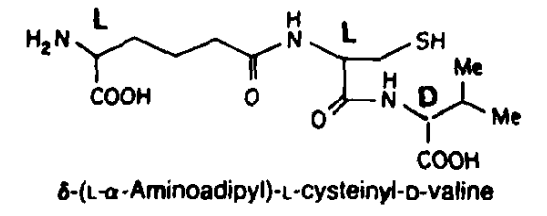
    
4. After ACV is made, next step is pcbC / isopenicillin N synthase. ACV is changed from a linear molecule into a bicyclic molecule. This happens by oxidative cyclization and it forms the β-lactam ring and the thiazolidine ring. So, this step gives the basic penicillin core, called isopenicillin N. The paper says ACV is oxidatively cyclized and forms the β-lactam-thiazolidine nucleus.

    Finally, penDE / acyltransferase changes the side chain. It removes the original side-chain type from isopenicillin N then adds the correct side chain for Penicillin G this side-chain modification makes the final biologically active chemical graph.

    For summarizing this process:

    pcbAB → ACV synthetase → makes linear ACV

    pcbC → isopenicillin N synthase → forms β-lactam and thiazolidine rings
    
    penDE → acyltransferase → changes side chain to make Penicillin G

## 3.3 ML Problem Formulation (1 pts)

**Essay Prompt:**
Assume you are designing a novel machine learning pipeline to predict the chemical structure of secondary metabolites directly from uncharacterized fungal genomic sequences.

Outline a formal Machine Learning problem statement for this task. Do not write any code. Address the following components:

1. **Inputs and Outputs:** Define the exact mathematical representation of your input data (e.g., raw nucleotides, extracted protein domain tokens) and your target output (e.g., SMILES strings, molecular graphs, molecular property classes).
2. **Architecture & Inductive Biases:** Propose a neural network architecture (e.g., Transformers, GNNs, CNNs, or a hybrid). Justify your choice based on the biological and chemical constraints of the problem. What specific inductive biases are necessary to map a sequence to a valid chemical graph?
3. **Evaluation Metrics:** How will you quantitatively evaluate the performance of your model? Specify at least two metrics suitable for your chosen output format.
4. **Data Availability constraint:** Search the MIBiG database documentation or literature to determine approximately how many *experimentally validated* BGC-to-compound pairs currently exist. Given this dataset size, discuss the feasibility of training your proposed architecture from scratch and suggest one strategy (e.g., pre-training, data augmentation, transfer learning) to mitigate data scarcity.


## Answer for 3.3

### 1. Task definition

I think this problem is a sequence-to-structure prediction task. We have one fungal biosynthetic gene cluster sequence (x), and we want the model to predict the metabolite structure (y), like this: f(x)=y.

### 2. Inputs and outputs

For the input, I will use the fungal genomic sequence of one candidate BGC:

$$
x=(n_1,n_2,\dots,n_L), \quad n_i \in \{A,C,G,T,N\}
$$

For these 'A,C,G,T,N', they can be encoded as a one-hot matrix:

$$
X \in \{0,1\}^{L \times 5}
$$

For the output, I will choose canonical SMILES string of the final metabolite. Because it is easier to train than full molecular graph.

### 3. Architecture and inductive biases

First, one Transformer encoder reads the nucleotide sequence. Then, one Transformer decoder generates the SMILES string. I choose Transformer mainly because the genomic sequence can be long, and the important genes may be far from each other. Also, the order of domains in a BGC is important for biosynthesis, so the model should understand sequence order.

The important inductive biases are: (1) nearby genes in one BGC should have related function; (2) DNA sequence and protein-domain information should both be used.

Chemical validity bias: the decoder should prefer legal SMILES, legal valence, and correct ring closure.

I think these biases are necessary, because the model is not only reading biology sequence, but also needs to generate a valid chemical structure.

### 4. Evaluation metrics

(1) Exact match accuracy

This checks whether the predicted canonical SMILES is exactly the same as the true answer.

(2) Tanimoto similarity

This compares molecular fingerprints between predicted molecule and true molecule. Even if the full SMILES is not exactly correct, this metric can show whether the predicted structure is still chemically similar.


(3) Valid SMILES rate

This means how many predicted SMILES strings can be parsed into real chemical structures. This is important because a model may output a text string that looks like SMILES but is actually invalid.

### 5. Data availability and feasibility

The data size is not very large. The database currently has 3,013 secondary metabolite clusters (https://mibig.secondarymetabolites.org/stats). Also, 2,437 of these entries have chemical structure annotations.

Because of this, I think training a big Transformer model from scratch is not very feasible, especially for fungal data only, because the fungal subset will be smaller than the full database. A better strategy is pre-training. We can first pre-train the encoder on many unlabeled fungal genome sequences (or other similar dataset), and then fine-tune on MIBiG.

### 6. Conclusion

In my opinion, this task can be written as a supervised sequence-to-SMILES generation problem. The input is fungal genomic sequence, and the output is a canonical SMILES. The Transfermor model needs some biological and chemical inductive biases, such as gene order, domain order, and chemical-validity constraints. For evaluation, I will use Exact Match Accuracy and Tanimoto Similarity, and Valid SMILES Rate. Since MIBiG only has around 3000 validated examples (much lower than this number for fungal subset), I think pre-training and then fine-tuning is more realistic.

